# 03 – Eksploratiivinen analyysi: täysistuntopuheet 2015–2026

Muistio kuvaa puheaineiston ennen mallinnusta. Aineisto on tehty muistioissa `01_aineiston_lataus` ja `02_siivous`.

Kysymykset:
1. Paljonko puhetta on kustakin puolueesta ja kaudesta, ja miten se jakautuu edustajien kesken?
2. Millaisia puheenvuoroja on (vastaus-, varsinaiset, ryhmä- ja ministerien puheenvuorot), ja eroavatko ne puolueittain tai hallitusaseman mukaan?
3. Mistä muusta kuin puolueesta luokittelija voisi oppia (hallitusasema, ministerit, aihe, kieli, muutama hyvin aktiivinen edustaja)?
4. Kuinka monta puhetta per puolue voidaan käyttää tasapainotetussa otoksessa?

Puoluelyhenteet: VAS = Vasemmistoliitto, SDP = Sosialidemokraatit, VIHR = Vihreät, KESK = Keskusta, RKP = Ruotsalainen kansanpuolue, KD = Kristillisdemokraatit, KOK = Kokoomus, SIN = Siniset (2017–2019), PS = Perussuomalaiset.

In [1]:
import sys
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sys.path.insert(0, "../src")
import config

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

KUVAT = "../reports/figures/"
PUOLUEET = config.PARTY_ORDER
VARIT = config.PARTY_COLORS
KAUDET = ["2015-2019", "2019-2023", "2023-2027"]

## 1. Aineisto ja otoksen rajaukset

In [2]:
sarakkeet = ["speech_id", "start_time", "term", "speech_type", "item_id", "person_id", "mp_name",
            "party", "in_government", "is_minister", "n_words_raw", "n_tokens", "share_swedish",
            "excl_empty", "excl_swedish", "excl_aland", "excl_no_party", "excl_small_party", "in_sample"]
kaikki = pd.read_parquet("../Data/processed/speeches_clean.parquet", columns=sarakkeet)
edustajat = pd.read_parquet("../Data/processed/mp_terms.parquet")

# Analyysiotos = puheet, joita mikään rajaus ei poista
puheet = kaikki[kaikki["in_sample"]].copy()

print("Puheita aineistossa:", len(kaikki))
print("Puheita analyysiotoksessa:", len(puheet))
print("Kansanedustajia otoksessa:", puheet["person_id"].nunique())

Puheita aineistossa: 133648
Puheita analyysiotoksessa: 130965
Kansanedustajia otoksessa: 370


Rajaukset on perusteltu muistiossa 02.

In [3]:
rajaukset = [
    ("excl_empty", "tyhjä puhe"),
    ("excl_swedish", "pääosin ruotsiksi (> 50 % sanoista)"),
    ("excl_aland", "Ahvenanmaan edustaja"),
    ("excl_no_party", "ei puoluetta / pieni tai yhden hengen ryhmä"),
    ("excl_small_party", "puolueella < 5 edustajaa kaudella"),
]

mukana = pd.Series(True, index=kaikki.index)
rivit = [("Kaikki puheet", len(kaikki))]
for sarake, selitys in rajaukset:
    poistettu = (mukana & kaikki[sarake]).sum()     # rajaus poistaa vain vielä mukana olevia
    mukana = mukana & ~kaikki[sarake]
    rivit.append(("  − " + selitys, poistettu))
rivit.append(("Analyysiotos", mukana.sum()))

pd.DataFrame(rivit, columns=["vaihe", "puheita"])

,vaihe,puheita
0,Kaikki puheet,133648
1,− tyhjä puhe,10
2,− pääosin ruotsiksi (> 50 % sanoista),1552
3,− Ahvenanmaan edustaja,270
4,− ei puoluetta / pieni tai yhden hengen ryhmä,851
5,− puolueella < 5 edustajaa kaudella,0
6,Analyysiotos,130965


## 2. Puheiden määrä puolueittain ja kausittain

In [4]:
puheita = pd.crosstab(puheet["party"], puheet["term"]).reindex(PUOLUEET)
edustajia = edustajat.groupby(["party", "term"])["person_id"].nunique().unstack().reindex(PUOLUEET)
puheita_per_edustaja = (puheita / edustajia).round(0)

print("Puheita:")
display(puheita)
print("Kansanedustajia (sisältää kauden aikana vaihtuneet):")
display(edustajia)
print("Puheita per edustaja:")
display(puheita_per_edustaja)

Puheita:


term,2015-2019,2019-2023,2023-2027
party,,,
VAS,4015,2769,2565
SDP,10577,8130,9962
VIHR,4046,3452,2772
KESK,11150,7738,5099
RKP,1185,964,630
KD,2462,1940,717
KOK,7575,8571,7868
SIN,1684,0,0
PS,7294,9413,8387


Kansanedustajia (sisältää kauden aikana vaihtuneet):


term,2015-2019,2019-2023,2023-2027
party,,,
VAS,12.0,18.0,14.0
SDP,37.0,40.0,46.0
VIHR,15.0,20.0,15.0
KESK,53.0,32.0,26.0
RKP,10.0,8.0,9.0
KD,5.0,5.0,5.0
KOK,42.0,41.0,52.0
SIN,20.0,NaN,NaN
PS,37.0,43.0,47.0


Puheita per edustaja:


term,2015-2019,2019-2023,2023-2027
party,,,
VAS,335.0,154.0,183.0
SDP,286.0,203.0,217.0
VIHR,270.0,173.0,185.0
KESK,210.0,242.0,196.0
RKP,118.0,120.0,70.0
KD,492.0,388.0,143.0
KOK,180.0,209.0,151.0
SIN,84.0,NaN,NaN
PS,197.0,219.0,178.0


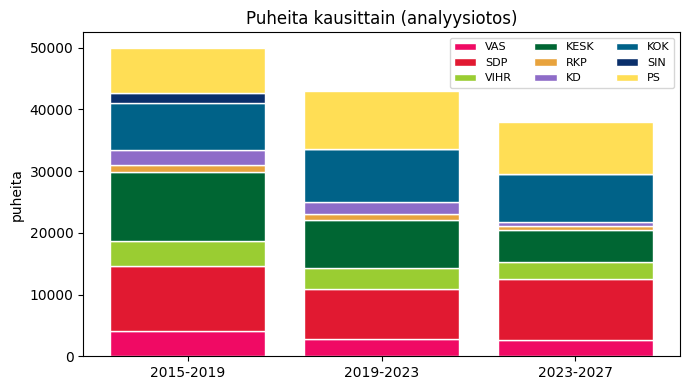

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
alaosa = np.zeros(len(KAUDET))
for puolue in PUOLUEET:
    maarat = puheita.loc[puolue].fillna(0).to_numpy()
    ax.bar(KAUDET, maarat, bottom=alaosa, color=VARIT[puolue], label=puolue, edgecolor="white")
    alaosa = alaosa + maarat
ax.set_title("Puheita kausittain (analyysiotos)")
ax.set_ylabel("puheita")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.savefig(KUVAT + "eda_puheita_kausittain.png")
plt.show()

### Puheet ajan mittaan
Puheita kuukaudessa. Katkoviiva = uusi eduskunta, pisteviiva = hallituksen vaihdos.

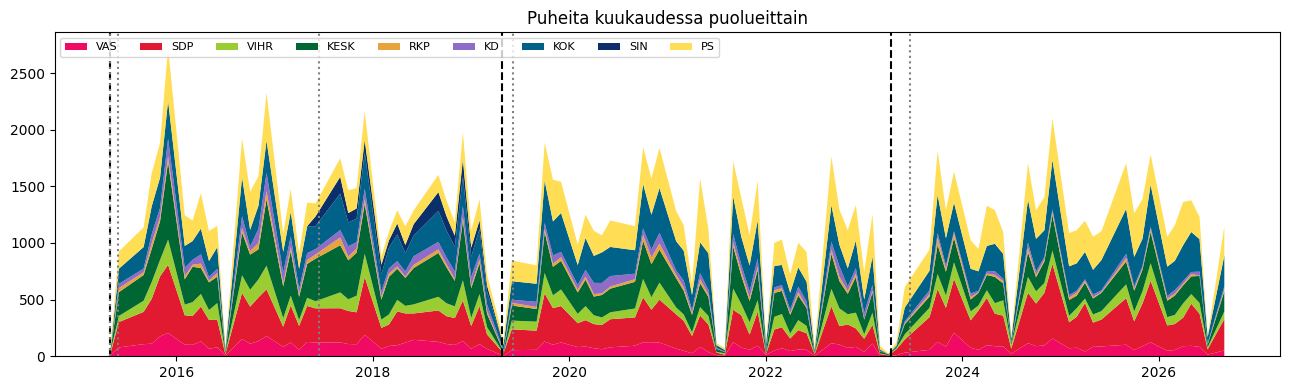

In [6]:
puheet["kuukausi"] = puheet["start_time"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()
kuukausittain = pd.crosstab(puheet["kuukausi"], puheet["party"])[PUOLUEET]

fig, ax = plt.subplots(figsize=(13, 4))
ax.stackplot(kuukausittain.index, kuukausittain.T.values,
             colors=[VARIT[p] for p in PUOLUEET], labels=PUOLUEET)
for nimi, alku in config.TERMS:
    ax.axvline(mdates.date2num(alku.tz_localize(None)), color="black", linestyle="--")
for nimi, alku, puolueet in config.GOVERNMENTS:
    ax.axvline(mdates.date2num(alku.tz_localize(None)), color="grey", linestyle=":")
ax.set_title("Puheita kuukaudessa puolueittain")
ax.legend(ncol=9, fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig(KUVAT + "eda_puheita_kuukausittain.png")
plt.show()

### Kuinka keskittynyttä puhuminen on?
Jos muutama edustaja pitää suurimman osan puolueen puheista, puhetason luokittelija (*classifier*) voi oppia tunnistamaan *nämä henkilöt* puolueen sijaan. Siksi opetus- ja testiaineisto (*training / test set*) jaetaan **edustajittain** (*grouped cross-validation*). Käsitteet on määritelty muistiossa 05.

In [7]:
# puheita per edustaja, kausi ja puolue
per_edustaja = puheet.groupby(["term", "party", "person_id"]).size().reset_index(name="puheita")

rivit = []
for (kausi, puolue), ryhma in per_edustaja.groupby(["term", "party"]):
    maarat = ryhma["puheita"].sort_values(ascending=False)
    osuus = maarat.head(3).sum() / maarat.sum()
    rivit.append({"kausi": kausi, "puolue": puolue, "kolmen aktiivisimman osuus": round(osuus, 2)})

keskittyminen = pd.DataFrame(rivit).pivot(index="puolue", columns="kausi",
                                          values="kolmen aktiivisimman osuus").reindex(PUOLUEET)
print("Puolueen kolmen aktiivisimman edustajan osuus puolueen puheista:")
keskittyminen

Puolueen kolmen aktiivisimman edustajan osuus puolueen puheista:


kausi,2015-2019,2019-2023,2023-2027
puolue,,,
VAS,0.47,0.31,0.36
SDP,0.22,0.27,0.25
VIHR,0.34,0.28,0.37
KESK,0.20,0.22,0.27
RKP,0.51,0.64,0.56
KD,0.71,0.77,0.70
KOK,0.30,0.20,0.27
SIN,0.42,NaN,NaN
PS,0.24,0.17,0.18


In [8]:
print("Puheita per edustaja ja kausi:")
per_edustaja.groupby("term")["puheita"].describe(percentiles=[0.1, 0.5, 0.9]).round(0)

Puheita per edustaja ja kausi:


,count,mean,std,min,10%,50%,90%,max
term,,,,,,,,
2015-2019,231.0,216.0,182.0,1.0,49.0,160.0,469.0,1013.0
2019-2023,207.0,208.0,155.0,1.0,45.0,168.0,416.0,875.0
2023-2027,214.0,178.0,154.0,2.0,43.0,142.0,315.0,1142.0


## 3. Puheenvuorojen tyypit

In [9]:
tyypit = ["vastaus", "varsinainen", "nopeatahtinen", "ryhmä", "esittely", "määrittelemätön"]
tyyppiosuudet = pd.crosstab(puheet["party"], puheet["speech_type"], normalize="index")
tyyppiosuudet.reindex(PUOLUEET)[tyypit].round(3)

speech_type,vastaus,varsinainen,nopeatahtinen,ryhmä,esittely,määrittelemätön
party,,,,,,
VAS,0.503,0.387,0.041,0.025,0.025,0.020
SDP,0.484,0.416,0.040,0.008,0.028,0.023
VIHR,0.505,0.381,0.047,0.021,0.021,0.025
KESK,0.483,0.391,0.046,0.010,0.028,0.042
RKP,0.598,0.236,0.038,0.032,0.028,0.067
KD,0.402,0.487,0.038,0.040,0.016,0.017
KOK,0.485,0.395,0.037,0.010,0.032,0.042
SIN,0.502,0.307,0.013,0.018,0.046,0.113
PS,0.384,0.497,0.047,0.009,0.036,0.026


In [10]:
puheet["asema"] = puheet["in_government"].map({True: "hallitus", False: "oppositio"})
asemittain = pd.crosstab([puheet["term"], puheet["asema"]], puheet["speech_type"], normalize="index")
asemittain[tyypit].round(3)

speech_type          vastaus  varsinainen  nopeatahtinen  ryhmä  esittely  määrittelemätön
term      asema                                                                           
2015-2019 hallitus     0.537        0.340          0.032  0.009     0.027            0.056
          oppositio    0.537        0.401          0.032  0.013     0.013            0.004
2019-2023 hallitus     0.434        0.383          0.051  0.015     0.050            0.066
          oppositio    0.361        0.547          0.054  0.012     0.022            0.005
2023-2027 hallitus     0.444        0.389          0.039  0.014     0.053            0.060
          oppositio    0.459        0.460          0.049  0.014     0.015            0.003

### Ministerit
Ministerit puhuvat hallituksen edustajina. Simola ym. pitävät heidät aineistossa, ja niin mekin, mutta luokittelija ajetaan myös ilman ministerien puheita.

In [11]:
ministeriosuus = puheet.groupby(["party", "term"])["is_minister"].mean().unstack().reindex(PUOLUEET)
print("Ministerien puheiden osuus puolueen puheista:")
ministeriosuus.round(3)

Ministerien puheiden osuus puolueen puheista:


term,2015-2019,2019-2023,2023-2027
party,,,
VAS,0.000,0.208,0.000
SDP,0.000,0.310,0.000
VIHR,0.000,0.249,0.001
KESK,0.231,0.246,0.000
RKP,0.000,0.359,0.384
KD,0.000,0.000,0.287
KOK,0.239,0.000,0.291
SIN,0.327,NaN,NaN
PS,0.108,0.000,0.215


## 4. Puheiden pituus

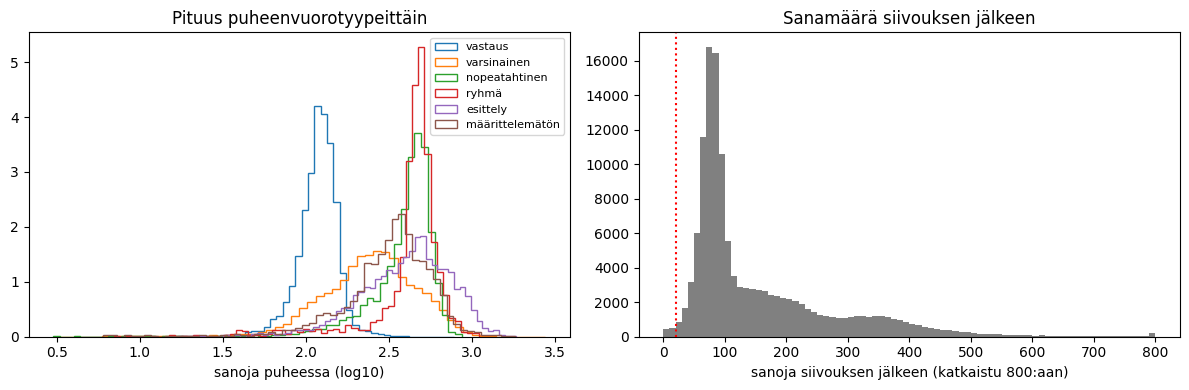

                   count   mean    std   min    10%    50%    90%     max
speech_type                                                              
esittely          3841.0  471.0  260.0  17.0  177.0  431.0  840.0  1850.0
määrittelemätön   4231.0  365.0  189.0   6.0  144.0  345.0  604.0  1831.0
nopeatahtinen     5518.0  413.0  137.0   3.0  218.0  432.0  569.0   875.0
ryhmä             1684.0  458.0  153.0   7.0  265.0  474.0  616.0  1111.0
varsinainen      54471.0  291.0  178.0   3.0  105.0  252.0  540.0  2781.0
vastaus          61220.0  122.0   34.0   4.0   84.0  121.0  158.0   779.0
Puheita, joissa alle 20 sanaa siivouksen jälkeen: 0.7%


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for tyyppi in tyypit:
    sanat = puheet.loc[puheet["speech_type"] == tyyppi, "n_words_raw"]
    ax[0].hist(np.log10(sanat.clip(lower=1)), bins=60, histtype="step", density=True, label=tyyppi)
ax[0].set_xlabel("sanoja puheessa (log10)")
ax[0].set_title("Pituus puheenvuorotyypeittäin")
ax[0].legend(fontsize=8)

ax[1].hist(puheet["n_tokens"].clip(upper=800), bins=80, color="grey")
ax[1].axvline(20, color="red", linestyle=":")
ax[1].set_xlabel("sanoja siivouksen jälkeen (katkaistu 800:aan)")
ax[1].set_title("Sanamäärä siivouksen jälkeen")

plt.tight_layout()
plt.savefig(KUVAT + "eda_puheiden_pituus.png")
plt.show()

print(puheet.groupby("speech_type")["n_words_raw"].describe(percentiles=[0.1, 0.5, 0.9]).round(0))
lyhyita = (puheet["n_tokens"] < 20).mean()
print(f"Puheita, joissa alle 20 sanaa siivouksen jälkeen: {lyhyita:.1%}")

## 5. Kieli
Ruotsinkieliset virkkeet poistettiin siivouksessa (muistio 02). Taulukko näyttää, paljonko ruotsia puolueiden puheissa oli ennen poistoa.

In [13]:
puheet["ruotsia"] = puheet["share_swedish"].fillna(0)
kieli = pd.DataFrame({
    "puheita, joissa ruotsia": (puheet["ruotsia"] > 0).groupby(puheet["party"]).mean(),
    "ruotsin osuus keskimäärin": puheet.groupby("party")["ruotsia"].mean(),
}).reindex(PUOLUEET)
kieli.round(3)

,"puheita, joissa ruotsia",ruotsin osuus keskimäärin
party,,
VAS,0.000,0.000
SDP,0.000,0.000
VIHR,0.000,0.000
KESK,0.000,0.000
RKP,0.008,0.001
KD,0.000,0.000
KOK,0.000,0.000
SIN,0.000,0.000
PS,0.000,0.000


## 6. Mistä puolueet puhuvat?
Projektisuunnitelman riski: puolueet voivat erota lähinnä *aiheen* eivätkä *puhetavan* perusteella.

**Käsiteltävien asioiden tyypit:** HE = hallituksen esitys, VNS = valtioneuvoston selonteko, VNT = valtioneuvoston tiedonanto, PI = pääministerin ilmoitus, K = kertomus, SKT = suullinen kysymys (kyselytunti), VK = välikysymys, LA/TPA/KA = edustajien aloitteet (laki-, toimenpide- ja keskustelualoite), KAA = kansalaisaloite.

In [14]:
puheet["asiakirjatyyppi"] = puheet["item_id"].fillna("").str.extract(r"^([A-ZÄÖ]+)")[0]
puheet["asiakirjatyyppi"] = puheet["asiakirjatyyppi"].fillna("ei tunnusta")

yleisimmat = puheet["asiakirjatyyppi"].value_counts().head(10).index
puheet["asiakirjatyyppi_10"] = puheet["asiakirjatyyppi"].where(puheet["asiakirjatyyppi"].isin(yleisimmat), "muu")
pd.crosstab(puheet["party"], puheet["asiakirjatyyppi_10"], normalize="index").reindex(PUOLUEET).round(3)

asiakirjatyyppi_10,HE,K,KA,KAA,LA,PI,SKT,VK,VNS,VNT,muu
party,,,,,,,,,,,
VAS,0.575,0.022,0.027,0.043,0.034,0.024,0.118,0.047,0.079,0.019,0.011
SDP,0.583,0.048,0.025,0.026,0.024,0.019,0.115,0.068,0.060,0.019,0.015
VIHR,0.529,0.031,0.032,0.048,0.027,0.025,0.132,0.061,0.079,0.020,0.016
KESK,0.564,0.028,0.026,0.029,0.023,0.019,0.150,0.060,0.072,0.017,0.011
RKP,0.461,0.014,0.047,0.046,0.017,0.035,0.204,0.054,0.083,0.027,0.013
KD,0.547,0.025,0.031,0.066,0.038,0.021,0.117,0.044,0.075,0.013,0.022
KOK,0.548,0.035,0.027,0.028,0.034,0.020,0.153,0.053,0.070,0.019,0.013
SIN,0.556,0.018,0.037,0.035,0.022,0.014,0.189,0.026,0.081,0.018,0.004
PS,0.558,0.037,0.026,0.043,0.055,0.016,0.114,0.051,0.070,0.017,0.013


**Puolueille tunnusomaisimmat sanat.** Mittarina on painotettu log-odds-suhde informatiivisella priorilla (*weighted log-odds ratio with informative Dirichlet prior*) (Monroe, Colaresi & Quinn 2008). Priori estää harvinaisia sanoja näyttämästä puoluesidonnaisilta sattumalta, mikä on juuri se ongelma, josta Gentzkow ym. varoittavat. Priorin idea: [SfDS 8.4.1](https://lacerbi.github.io/stats-for-ds-website/chapters/08-bayesian-inference-decision-theory.html#conjugate-models-and-conjugate-priors). Sanat ovat vartaloita, ja nimet ja puolueiden nimet on poistettu.

In [15]:
# Liitetään siivotut sanat (tokens) puheisiin
sanat = pd.read_parquet("../Data/processed/speeches_clean.parquet", columns=["speech_id", "tokens"])
puheet = puheet.merge(sanat, on="speech_id", how="left")
del sanat


def laske_sanat(teksti_lista):
    """Laskee sanat listasta siivottuja puheita. Merkki '|' on poistetun sanan paikka."""
    laskuri = Counter()
    for teksti in teksti_lista:
        for sana in teksti.split():
            if sana != "|":
                laskuri[sana] += 1
    return laskuri


def tunnusomaiset_sanat(aineisto, ryhmasarake, n=15, vahintaan=200):
    """Kullekin ryhmälle n tunnusomaisinta sanaa (log-odds informatiivisella priorilla)."""
    ryhmien_sanat = {}
    for ryhma, osa in aineisto.groupby(ryhmasarake):
        ryhmien_sanat[ryhma] = laske_sanat(osa["tokens"])

    kaikki_sanat = Counter()
    for laskuri in ryhmien_sanat.values():
        kaikki_sanat.update(laskuri)
    N = sum(kaikki_sanat.values())
    a0 = 0.01 * N                      # priorin vahvuus

    tulos = {}
    for ryhma, laskuri in ryhmien_sanat.items():
        n_ryhma = sum(laskuri.values())
        pisteet = []
        for sana, f in laskuri.items():
            yhteensa = kaikki_sanat[sana]
            if yhteensa < vahintaan:
                continue
            muut = yhteensa - f
            a = a0 * yhteensa / N      # sanan priori
            logodds_ryhma = np.log((f + a) / (n_ryhma + a0 - f - a))
            logodds_muut = np.log((muut + a) / (N - n_ryhma + a0 - muut - a))
            varianssi = 1 / (f + a) + 1 / (muut + a)
            z = (logodds_ryhma - logodds_muut) / np.sqrt(varianssi)
            pisteet.append((z, sana))
        pisteet.sort(reverse=True)
        tulos[ryhma] = [sana for z, sana in pisteet[:n]]
    return pd.DataFrame(tulos)

In [16]:
kausi = puheet[puheet["term"] == "2023-2027"]
tunnusomaiset_sanat(kausi, "party")[[p for p in PUOLUEET if p in kausi["party"].unique()]]

,VAS,SDP,VIHR,KESK,RKP,KD,KOK,PS
0,leikkauks,sit,luono,itäis,myösk,eutanasia,uudistuks,rikoks
1,pienitulois,työeläm,ilmasto,pohjois,koulu,tuottaj,nato,ehdot
2,ydinas,leikkauks,päästöj,lähipalvelu,panost,hamas,vahvist,maahanmuuttopolitiik
3,toimeentulotue,työntekijö,eläint,maaseudu,tosi,metsätalousministeriö,turvallisuus,poliis
4,asumistue,palkansaaj,ympäristö,maakun,oppimis,myösk,ukrain,maahanmuuto
5,asumistuk,työttömyysturv,ilmastotoim,maataloud,opettaj,maataloud,teem,koskev
6,vuokr,tääl,luontokado,pitä,tiete,maaseudu,tärkeä,maahanmuuttaj
7,leika,työnantaj,luonto,juna,tärkeä,elik,venäj,kansalaisuud
8,asem,heikennyks,vihreä,karjal,koulutuks,kysyi,vahv,maas
9,sosiaaliturvaleikkauks,työttöm,hiilinielu,mets,kysyi,nimenomais,turvallisuut,henkilö


In [17]:
kausi = puheet[puheet["term"] == "2015-2019"]
tunnusomaiset_sanat(kausi, "party")[[p for p in PUOLUEET if p in kausi["party"].unique()]]

,VAS,SDP,VIHR,KESK,RKP,KD,KOK,SIN,PS
0,kuink,eläkkeensaaj,ilmastonmuutoks,mets,vaasa,avioliito,eli,puolustusvoim,lakialoit
1,työntekijö,hallituspuolue,hallitus,erit,ihmiskaup,kirko,varhaiskasvatuks,ehdot,maahanmuuto
2,työttöm,hallitus,leikkauks,myösk,keskussairaal,potil,kirjasto,afganistan,henkilö
3,ongelm,hallituks,koulutuks,maakun,pohjanm,isä,tietyst,kasvupalvelu,turvapaikanhakij
4,opiskelij,minister,luono,alue,sairaal,sukupuolineutraal,myösk,operaatio,kans
5,ceta,valiokun,ympäristövaliokun,pysty,miele,äid,koulutuks,muutettav,yle
6,leika,yleisradio,saamelaist,as,mite,eutanasia,työn,metsästäj,tosia
7,mitenk,leika,mite,maataloud,hallitus,lääkär,lakivaliokun,esityks,laittom
8,opintotue,sosiaalidemokraat,ilmasto,kun,ehk,laps,poliis,koskev,kehitysapu
9,tuloero,pääminister,ympäristö,eteenp,päivystyks,abort,reform,sotilaallis,rikoks


**Hallituksen ja opposition sanasto** (kaikki kaudet yhdessä). Jos samat sanat ovat myös puolueiden listoilla, puolueluokittelija on osittain hallitus–oppositio-luokittelija. Tätä mittaa kontrollitehtävä (*control task*, muistio 05).

In [18]:
tunnusomaiset_sanat(puheet, "asema", n=20)

,hallitus,oppositio
0,tärkeä,hallituks
1,myös,hallitus
2,myösk,leikkauks
3,yhteistyö,hallituspuolue
4,tärk,pääminister
5,hallitusohjelm,leika
6,vahvist,pitäi
7,erit,minister
8,teem,kysy
9,oppositio,vastalaus


## 7. Johtopäätökset mallinnukselle

1. **Määrä.** Noin 130 000 puhetta, 38 000–50 000 per kausi. Isoilla puolueilla (SDP, KESK, KOK, PS) on 5 000–11 000 puhetta kaudessa, RKP:llä 630–1 200 ja KD:llä 700–2 500 (5 edustajaa). 300 opetuspuhetta per puolue per osio onnistuu joka kaudella; tiukimmalla ovat RKP ja KD kaudella 2023–27.
2. **Pienissä puolueissa muutama edustaja pitää suurimman osan puheista:** KD:ssä kolme edustajaa noin 70 %, RKP:ssä 50–65 %. Siksi aineisto jaetaan opetukseen ja testaukseen edustajittain, ja KD:n ja RKP:n tulokset ovat epävarmoja.
3. **Puheenvuorotyypit.** 47 % on vastauspuheenvuoroja (mediaani 120 sanaa) ja 42 % varsinaisia puheenvuoroja. Oppositio pitää suhteessa enemmän varsinaisia puheenvuoroja. Vain 0,7 %:ssa puheista on alle 20 sanaa siivouksen jälkeen.
4. **Ministerit** pitävät yleensä 20–38 % hallituspuolueen puheista (PS 2015–19: 11 %, koska puolue lähti hallituksesta 2017). Luokittelija ajetaan myös ilman heitä.
5. **Ruotsi.** Siivouksen jälkeen ruotsia ei käytännössä ole. Pääosin ruotsinkieliset puheet, lähes kaikki RKP:ltä, on rajattu pois.
6. **Aihe vs. puhetapa.** Käsiteltävät asiat ovat kaikille puolueille samoja (noin puolet puheista koskee hallituksen esityksiä), mutta sanastot eroavat ennen kaikkea aiheiltaan:
   - PS: maahanmuutto ja rikokset
   - VIHR: ilmasto ja luonto
   - KESK: alueet ja maatalous
   - VAS: pienituloiset ja leikkaukset
   - SDP: työelämä
   - KOK: turvallisuus ja Nato
   - RKP: koulutus
   - KD: eutanasia ja avioliitto

   Sanamääriin perustuva luokittelija ei erota, *mitä* sanotaan ja *miten*. Tulokset kuvataan siksi muodossa "mistä puolueet puhuvat ja millä sanoilla".
7. **Hallitus ja oppositio** puhuvat eri sanoin: oppositio *hallitus*, *leikkaus*, *heikennys*; hallitus *yhteistyö*, *hallitusohjelma*, *vahvistaa*. Kontrollitehtävä on siksi välttämätön.
8. **Murre ja puhetyyli** (*sit*, *tääl*, *myösk*) ovat tunnusomaisimpien sanojen joukossa. Simola ym. vakioivat alueen; me emme vielä (vaalipiiri saadaan kansanedustajarekisteristä).